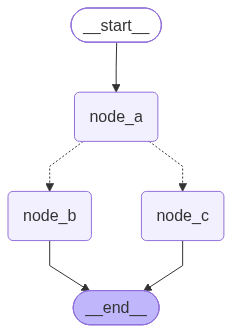

In [11]:
from typing import TypedDict

from langgraph.graph import START,END,StateGraph
from IPython.display import Image,display

class State(TypedDict):
    x: int
    
def node_a(state:State):
    return {'x':state['x']+1}

def node_b(state:State):
    return {'x':state['x']-2}

def node_c(state:State):
    return {'x':state['x']+2}

def routing_function(state:State):
    if state['x']==10:
        return 'node_b'
    else:
        return 'node_c'
    
builder=StateGraph(dict)

builder.add_node('node_a',node_a)
builder.add_node('node_b',node_b)
builder.add_node('node_c',node_c)

# builder.set_entry_point('node_a')

builder.add_edge(START,'node_a')
builder.add_conditional_edges("node_a",routing_function,
                              {
                                  'node_b':'node_b',
                                  'node_c':'node_c'
                              })

# builder.add_edge("node_b", END)
# builder.add_edge("node_c", END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))